# Analítica de Dados Empresariais
# Mestrado em Ciência de Dados para Empresas
## Machine Learning – Previsão de Telco Churn (Regresão Logística)


## 1. Importação das bibliotecas

In [2]:
# Ignorar avisos menos relevantes
import warnings
warnings.filterwarnings("ignore")

# Bibliotecas principais de análise
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Avaliação
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix


# Mostrar pipelines em diagrama
from sklearn import set_config
set_config(display="diagram")


## 2. Carregar o dataset

In [4]:
#Precisamos desta biblioteca para podermos escolher um ficheiro local
#Se o ficheiro vier por API ou tivermos um link, é so alterar a forma de import
from google.colab import files

# 1️⃣ Faz upload do ficheiro (vai abrir uma janela para escolher no teu PC)
uploaded = files.upload()

# 2️⃣ Guarda o nome do ficheiro (Colab mostra o nome depois do upload)
filename = list(uploaded.keys())[0]

# 3️⃣ Lê o Excel, por default lê sempre a primeira tab, por isso podemos usar o "sheet_name"
# Se tivermos dados em varias tabs, devemos usar uma Dataframe(df) para cada uma das tabs
df = pd.read_excel(filename, sheet_name='tab1')
df.head()

print("Dataset carregado com sucesso")
print("Dimensão:", df.shape)

print("\nPrimeiras linhas:")
print(df.head().to_string(index=False))


Saving WA_Fn-UseC_-Telco-Customer-Churn_CleanData.xlsx to WA_Fn-UseC_-Telco-Customer-Churn_CleanData.xlsx
Dataset carregado com sucesso
Dimensão: (7043, 21)

Primeiras linhas:
customerID gender  SeniorCitizen Partner Dependents  tenure PhoneService    MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies       Contract PaperlessBilling             PaymentMethod  MonthlyCharges  TotalCharges  Churn
7590-VHVEG Female              0     Yes         No       1           No No phone service             DSL             No          Yes               No          No          No              No Month-to-month              Yes          Electronic check           29.85         29.85      0
5575-GNVDE   Male              0      No         No      34          Yes               No             DSL            Yes           No              Yes          No          No              No       One year               No              Mailed check    

## 3. Compreender e limpar os dados

In [5]:
print("Número de clientes:", len(df))

print("\nInformação estrutural:")
df.info()

print("\nTipos de dados:")
print(df.dtypes)

Número de clientes: 7043

Informação estrutural:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object

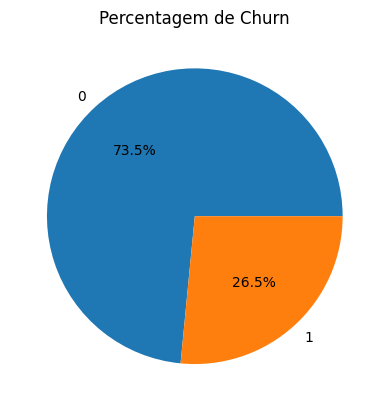

In [9]:
# Percentagem de Churn
churn_counts = df['Churn'].value_counts(normalize=True)

plt.figure()
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%')
plt.title('Percentagem de Churn')
plt.show()

In [25]:
df['PaymentMethod'].value_counts(dropna=False)

,count
PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


## 4. Definição das variáveis

In [26]:
# "Churn"  customerID "gender", "SeniorCitizen" "Partner""Dependents""tenure""PhoneService""MultipleLines""InternetService""OnlineSecurity""OnlineBackup""DeviceProtection""TechSupport"
#"StreamingTV""StreamingMovies""Contract""PaperlessBilling""PaymentMethod""MonthlyCharges""TotalCharges"

target="Churn"

features=[
"gender",
"SeniorCitizen",
"Partner",
"Dependents",
"tenure",
"PhoneService",
"MultipleLines",
"InternetService",
"OnlineSecurity",
"OnlineBackup",
"DeviceProtection",
"TechSupport",
"StreamingTV",
"StreamingMovies",
"Contract",
"PaperlessBilling",
"PaymentMethod",
"MonthlyCharges",
"TotalCharges"
]

X=df[features]
y=df[target]

print("Variável alvo:",target)
print("\nVariáveis explicativas:")

for f in features:
    print("-",f)


Variável alvo: Churn

Variáveis explicativas:
- gender
- SeniorCitizen
- Partner
- Dependents
- tenure
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaperlessBilling
- PaymentMethod
- MonthlyCharges
- TotalCharges


## 5. Tipos de variáveis

In [27]:
# "Churn"  customerID "gender", "SeniorCitizen" "Partner""Dependents""tenure""PhoneService""MultipleLines""InternetService""OnlineSecurity""OnlineBackup""DeviceProtection""TechSupport"
#"StreamingTV""StreamingMovies""Contract""PaperlessBilling""PaymentMethod""MonthlyCharges""TotalCharges"

num=[
"MonthlyCharges",
"tenure",
"TotalCharges"
]

cat=[
"gender",
"SeniorCitizen",
"Partner",
"Dependents",
"PhoneService",
"MultipleLines",
"InternetService",
"OnlineSecurity",
"OnlineBackup",
"DeviceProtection",
"TechSupport",
"StreamingTV",
"StreamingMovies",
"Contract",
"PaperlessBilling",
"PaymentMethod"
]

print("Numéricas:",num)
print("Categóricas:",cat)


Numéricas: ['MonthlyCharges', 'tenure', 'TotalCharges']
Categóricas: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 6. Divisão treino/teste

In [28]:
X_train,X_test,y_train,y_test=train_test_split(
X,y,
test_size=0.25,
random_state=42,
stratify=y
)

print("Treino:",X_train.shape)
print("Teste:",X_test.shape)


Treino: (5282, 19)
Teste: (1761, 19)


## 7. Pipeline de preparação dos dados

In [29]:
num_pipe=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
    ])
cat_pipe=Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
    ])
prep=ColumnTransformer([
    ("num",num_pipe,num),
    ("cat",cat_pipe,cat)
    ])
print("Pipeline de preparação criado com sucesso")

display(prep)


Pipeline de preparação criado com sucesso


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['MonthlyCharges', 'tenure', 'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

## 8. Construção do modelo

In [30]:
model=Pipeline([
("prep",prep),
("clf",LogisticRegression(max_iter=1000,class_weight="balanced"))
])

model.fit(X_train,y_train)

print("Modelo treinado com sucesso")

display(model)


Modelo treinado com sucesso


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyCharges', 'tenure',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

## 9. Avaliação do modelo e Coefecientes

In [44]:
preprocessor = model.named_steps["prep"]

feature_names_num = num

onehot = preprocessor.named_transformers_["cat"]

feature_names_cat = onehot.get_feature_names_out(cat)

all_features = list(feature_names_num) + list(feature_names_cat)

coef = model.named_steps["clf"].coef_[0]

coef_df = pd.DataFrame({
    "Variável": all_features,
    "Coeficiente": coef
}).sort_values(by="Coeficiente", ascending=False)

coef_df

,Variável,Coeficiente
17,InternetService_Fiber optic,0.687781
37,Contract_Month-to-month,0.648406
2,TotalCharges,0.521270
36,StreamingMovies_Yes,0.290754
33,StreamingTV_Yes,0.246467
44,PaymentMethod_Electronic check,0.213872
19,OnlineSecurity_No,0.213333
28,TechSupport_No,0.181370
15,MultipleLines_Yes,0.139226
41,PaperlessBilling_Yes,0.100258


              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1294
           1       0.52      0.80      0.63       467

    accuracy                           0.75      1761
   macro avg       0.71      0.76      0.72      1761
weighted avg       0.81      0.75      0.76      1761

ROC AUC: 0.8461206226067272


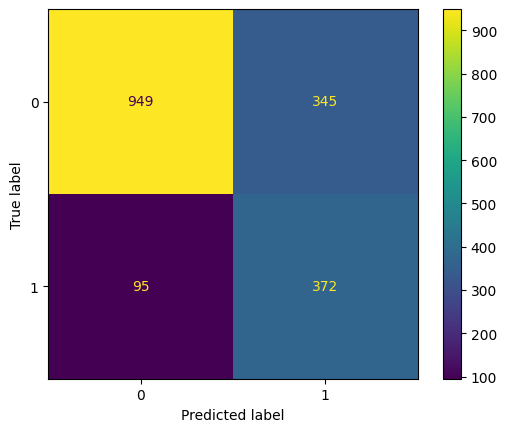

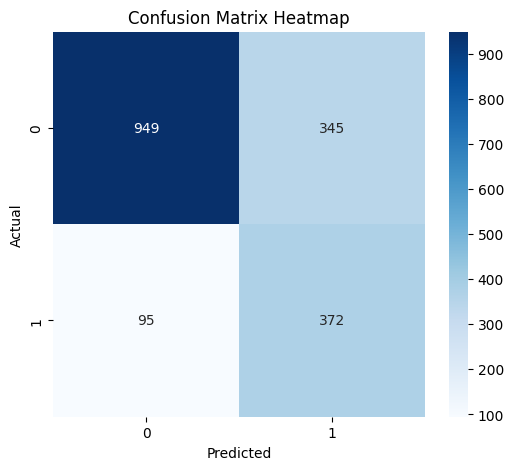

In [31]:
pred=model.predict(X_test)
proba=model.predict_proba(X_test)[:,1]

print(classification_report(y_test,pred))

print("ROC AUC:",roc_auc_score(y_test,proba))

ConfusionMatrixDisplay.from_predictions(y_test,pred)
plt.show()


# Gerar matriz de confusão
cm = confusion_matrix(y_test, pred, labels=y_test.unique())

# Criar DataFrame para labels
cm_df = pd.DataFrame(cm, index=y_test.unique(), columns=y_test.unique())

# Plotar heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix Heatmap")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

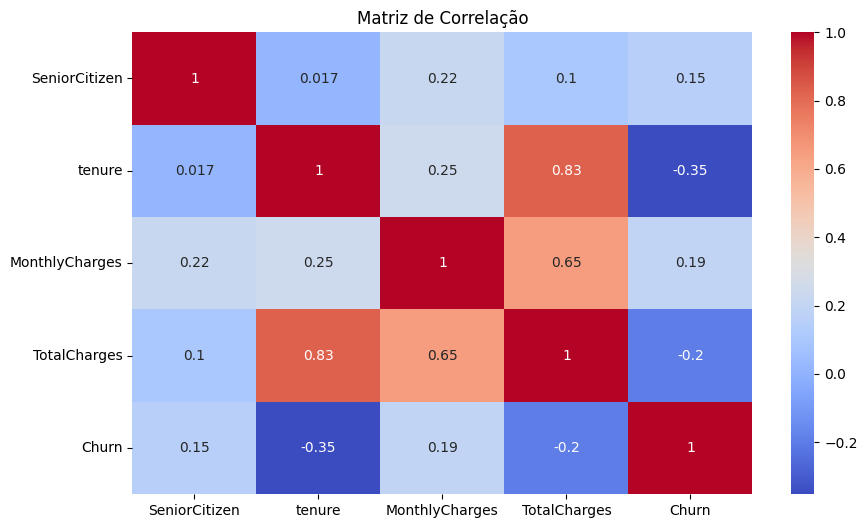

In [37]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')

plt.show()

## 10. Cálculo do risco de churn (Decision Engine)

In [32]:
df_scored=df.copy()

df_scored["Churn"]=model.predict_proba(X)[:,1]

#0 no Churn é não, enquanto 1 é Sim, quanto mais proximo do 1, maior probabilidade de Churn
print("Maior risco:",df_scored["Churn"].max())

print(df_scored[["customerID","Churn"]].head().to_string(index=False))


Maior risco: 0.9386570256743881
customerID    Churn
7590-VHVEG 0.791213
5575-GNVDE 0.120119
3668-QPYBK 0.538228
7795-CFOCW 0.074838
9237-HQITU 0.854206


## 11. Estratégia de retenção (Decision Engine)

In [33]:
def action(r):

    if r >= 0.70:
        return "Intervenção urgente (oferta forte / contacto direto)"

    if r >= 0.50:
        return "Campanha de retenção (desconto / benefício)"

    if r >= 0.30:
        return "Monitorização + comunicação leve (email / push)"

    return "Sem ação (cliente estável)"

df_scored["Recomendacao"] = df_scored["Churn"].apply(action)

print(df_scored["Recomendacao"].value_counts())


Recomendacao
Sem ação (cliente estável)                              2983
Intervenção urgente (oferta forte / contacto direto)    1766
Monitorização + comunicação leve (email / push)         1173
Campanha de retenção (desconto / benefício)             1121
Name: count, dtype: int64


## 12. Distribuição das estratégias

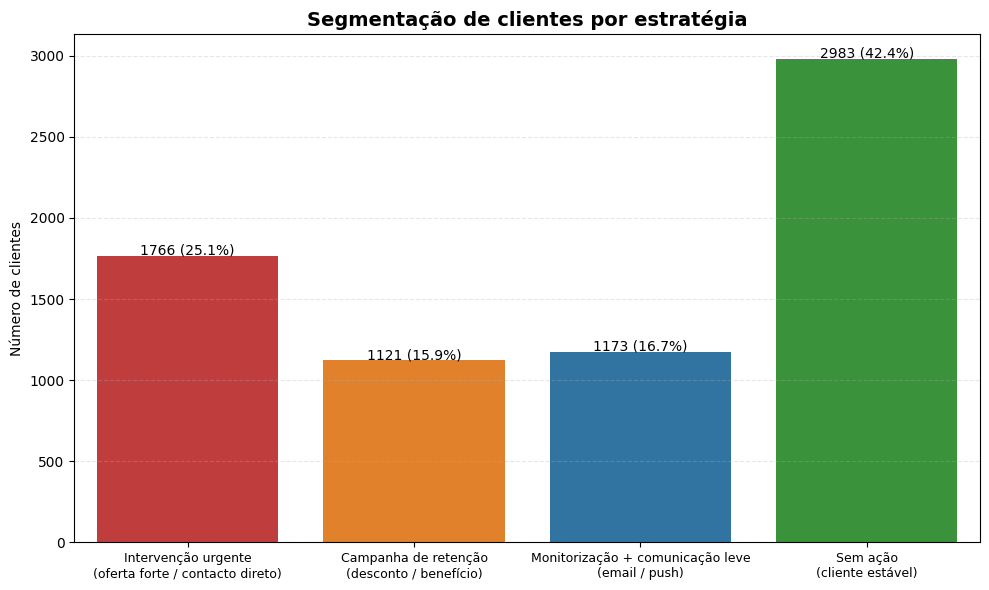

In [34]:
# Contagem e ordenação por nível de risco
ordem = [
    "Intervenção urgente (oferta forte / contacto direto)",
    "Campanha de retenção (desconto / benefício)",
    "Monitorização + comunicação leve (email / push)",
    "Sem ação (cliente estável)"
]

# Criar cópia apenas para melhorar os rótulos do gráfico
df_plot = df_scored.copy()

df_plot["Recomendacao_plot"] = df_plot["Recomendacao"].replace({
    "Intervenção urgente (oferta forte / contacto direto)":"Intervenção urgente (oferta forte / contacto direto)",
    "Campanha de retenção (desconto / benefício)": "Campanha de retenção (desconto / benefício)",
     "Monitorização + comunicação leve (email / push)":  "Monitorização + comunicação leve (email / push)",
    "Sem ação (cliente estável)": "Sem ação (cliente estável)"
})

counts = df_plot["Recomendacao_plot"].value_counts().reindex(ordem)

# Percentagens
percent = counts / counts.sum() * 100

# Cores por criticidade
cores = ["#d62728", "#ff7f0e", "#1f77b4", "#2ca02c"]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=counts.index,
    y=counts.values,
    palette=cores
)

plt.title("Segmentação de clientes por estratégia", fontsize=14, weight="bold")
plt.xlabel("")
plt.ylabel("Número de clientes")

# alterar labels do eixo X
labels = [
    "Intervenção urgente\n(oferta forte / contacto direto)",
    "Campanha de retenção\n(desconto / benefício)",
    "Monitorização + comunicação leve\n(email / push)",
    "Sem ação\n(cliente estável)"
]

ax.set_xticklabels(labels, fontsize=9)

# Valores e percentagens
for i, (val, pct) in enumerate(zip(counts.values, percent)):
    ax.text(i, val + 8, f"{val} ({pct:.1f}%)", ha="center", fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


## 13. Clientes prioritários

In [35]:
# "Churn"  customerID "gender", "SeniorCitizen" "Partner""Dependents""tenure""PhoneService""MultipleLines""InternetService""OnlineSecurity""OnlineBackup""DeviceProtection""TechSupport"
#"StreamingTV""StreamingMovies""Contract""PaperlessBilling""PaymentMethod""MonthlyCharges""TotalCharges"

clientes_prioritarios=df_scored.sort_values(
"Churn",
ascending=False
)[[
"customerID",
"gender",
"SeniorCitizen",
"Partner",
"Dependents",
"tenure",
"MultipleLines",
"InternetService",
"OnlineSecurity",
"OnlineBackup",
"OnlineBackup",
"DeviceProtection"
]].head(20)

print("CLIENTES PRIORITÁRIOS")
print(clientes_prioritarios.to_string(index=False))


CLIENTES PRIORITÁRIOS
customerID gender  SeniorCitizen Partner Dependents  tenure MultipleLines InternetService OnlineSecurity OnlineBackup OnlineBackup DeviceProtection
9497-QCMMS   Male              1      No         No       1           Yes     Fiber optic             No           No           No               No
9300-AGZNL   Male              1      No         No       1           Yes     Fiber optic             No           No           No               No
4424-TKOPW   Male              1      No         No       2           Yes     Fiber optic             No           No           No               No
2720-WGKHP   Male              1      No         No       2           Yes     Fiber optic             No           No           No               No
5178-LMXOP   Male              1     Yes         No       1           Yes     Fiber optic             No           No           No               No
7024-OHCCK Female              1      No         No       2           Yes     Fiber optic 

## 14. Distribuição do risco

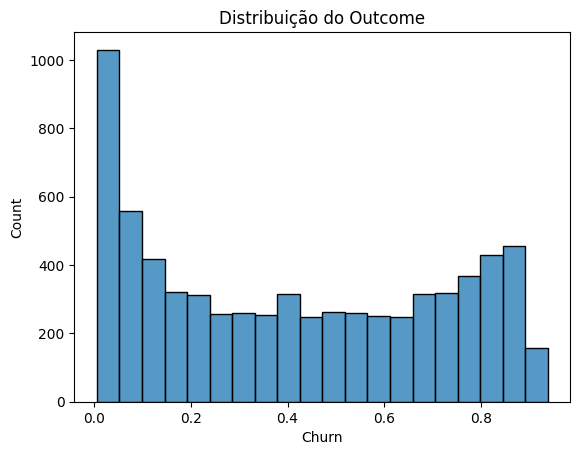

In [36]:
sns.histplot(df_scored["Churn"],bins=20)
plt.title("Distribuição do Outcome")
plt.show()
